Dataset shape: (4600, 18)

First 5 rows:

Data types:
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object

Summary statistics:
No missing values found.


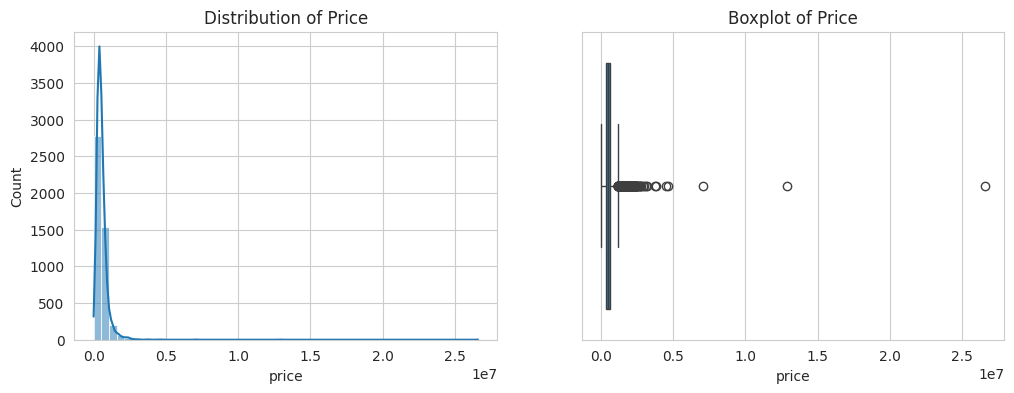

Number of outlier properties (price > 3σ): 34 (0.74%)


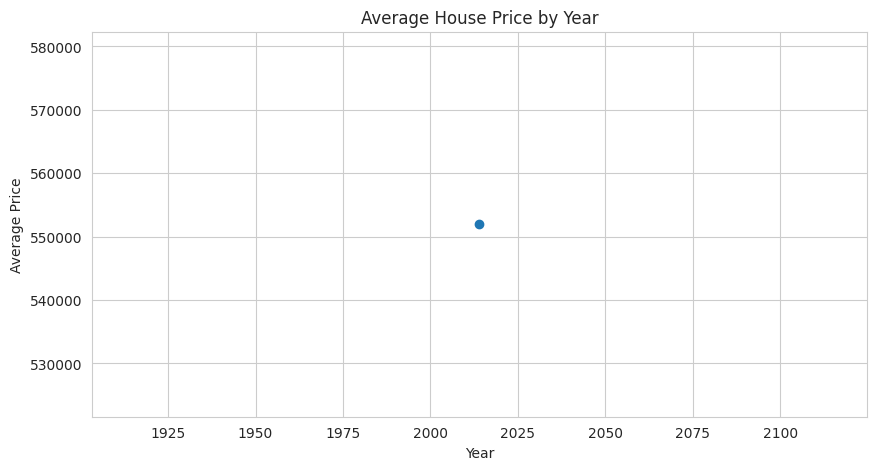


street: 4525 unique values
street
2520 Mulberry Walk NE    4
2500 Mulberry Walk NE    3
2803 SW Bataan St        2
8354 11th Ave NW         2
6008 8th Ave NE          2
14634 128th Ave NE       2
8430 8th Ave SW          2
11034 NE 26th Pl         2
5010 Greenwood Ave N     2
9413 34th Ave SW         2
Name: count, dtype: int64

city: 44 unique values
city
Seattle        1573
Renton          293
Bellevue        286
Redmond         235
Kirkland        187
Issaquah        187
Kent            185
Auburn          176
Sammamish       175
Federal Way     148
Name: count, dtype: int64

statezip: 77 unique values
statezip
WA 98103    148
WA 98052    135
WA 98117    132
WA 98115    130
WA 98006    110
WA 98059    106
WA 98042    100
WA 98034     99
WA 98053     98
WA 98074     98
Name: count, dtype: int64

country: 1 unique values
country
USA    4600
Name: count, dtype: int64


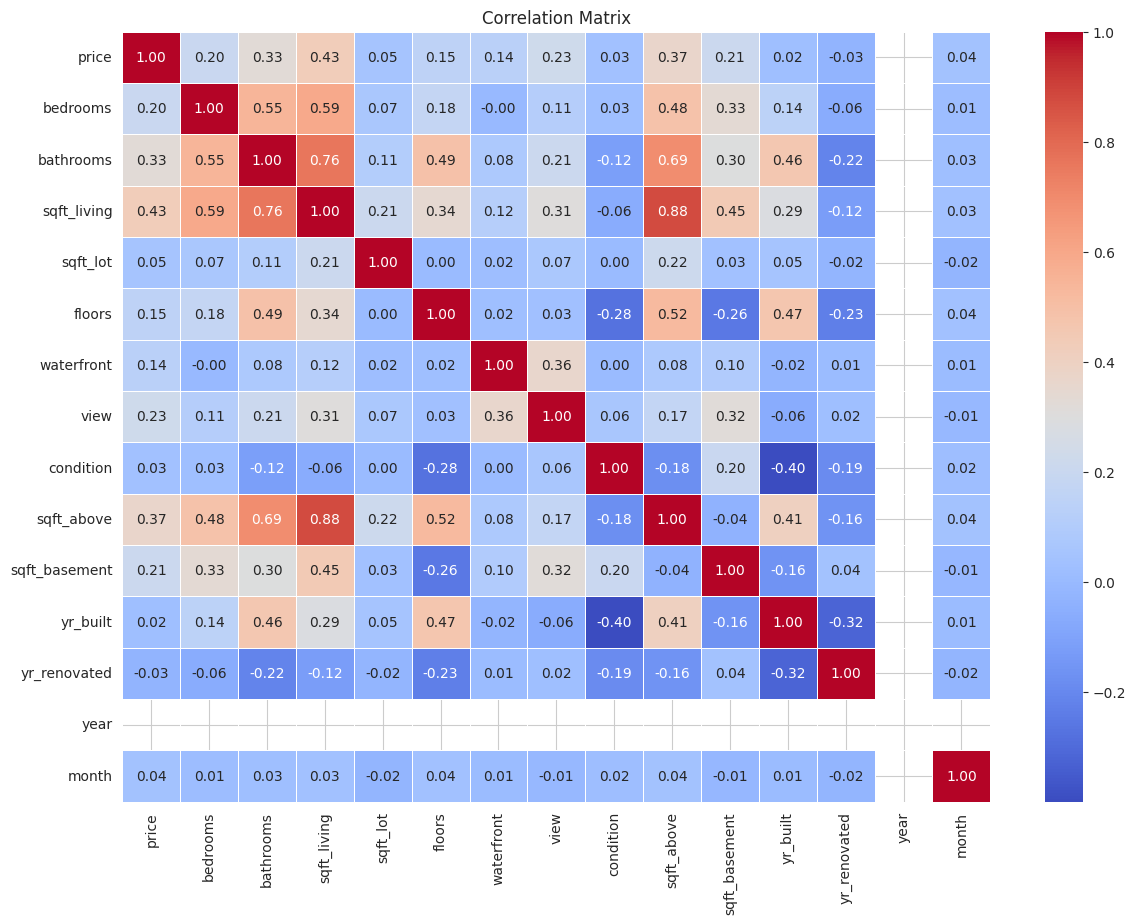

Top 10 features correlated with price:
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
month            0.041081
Name: price, dtype: float64


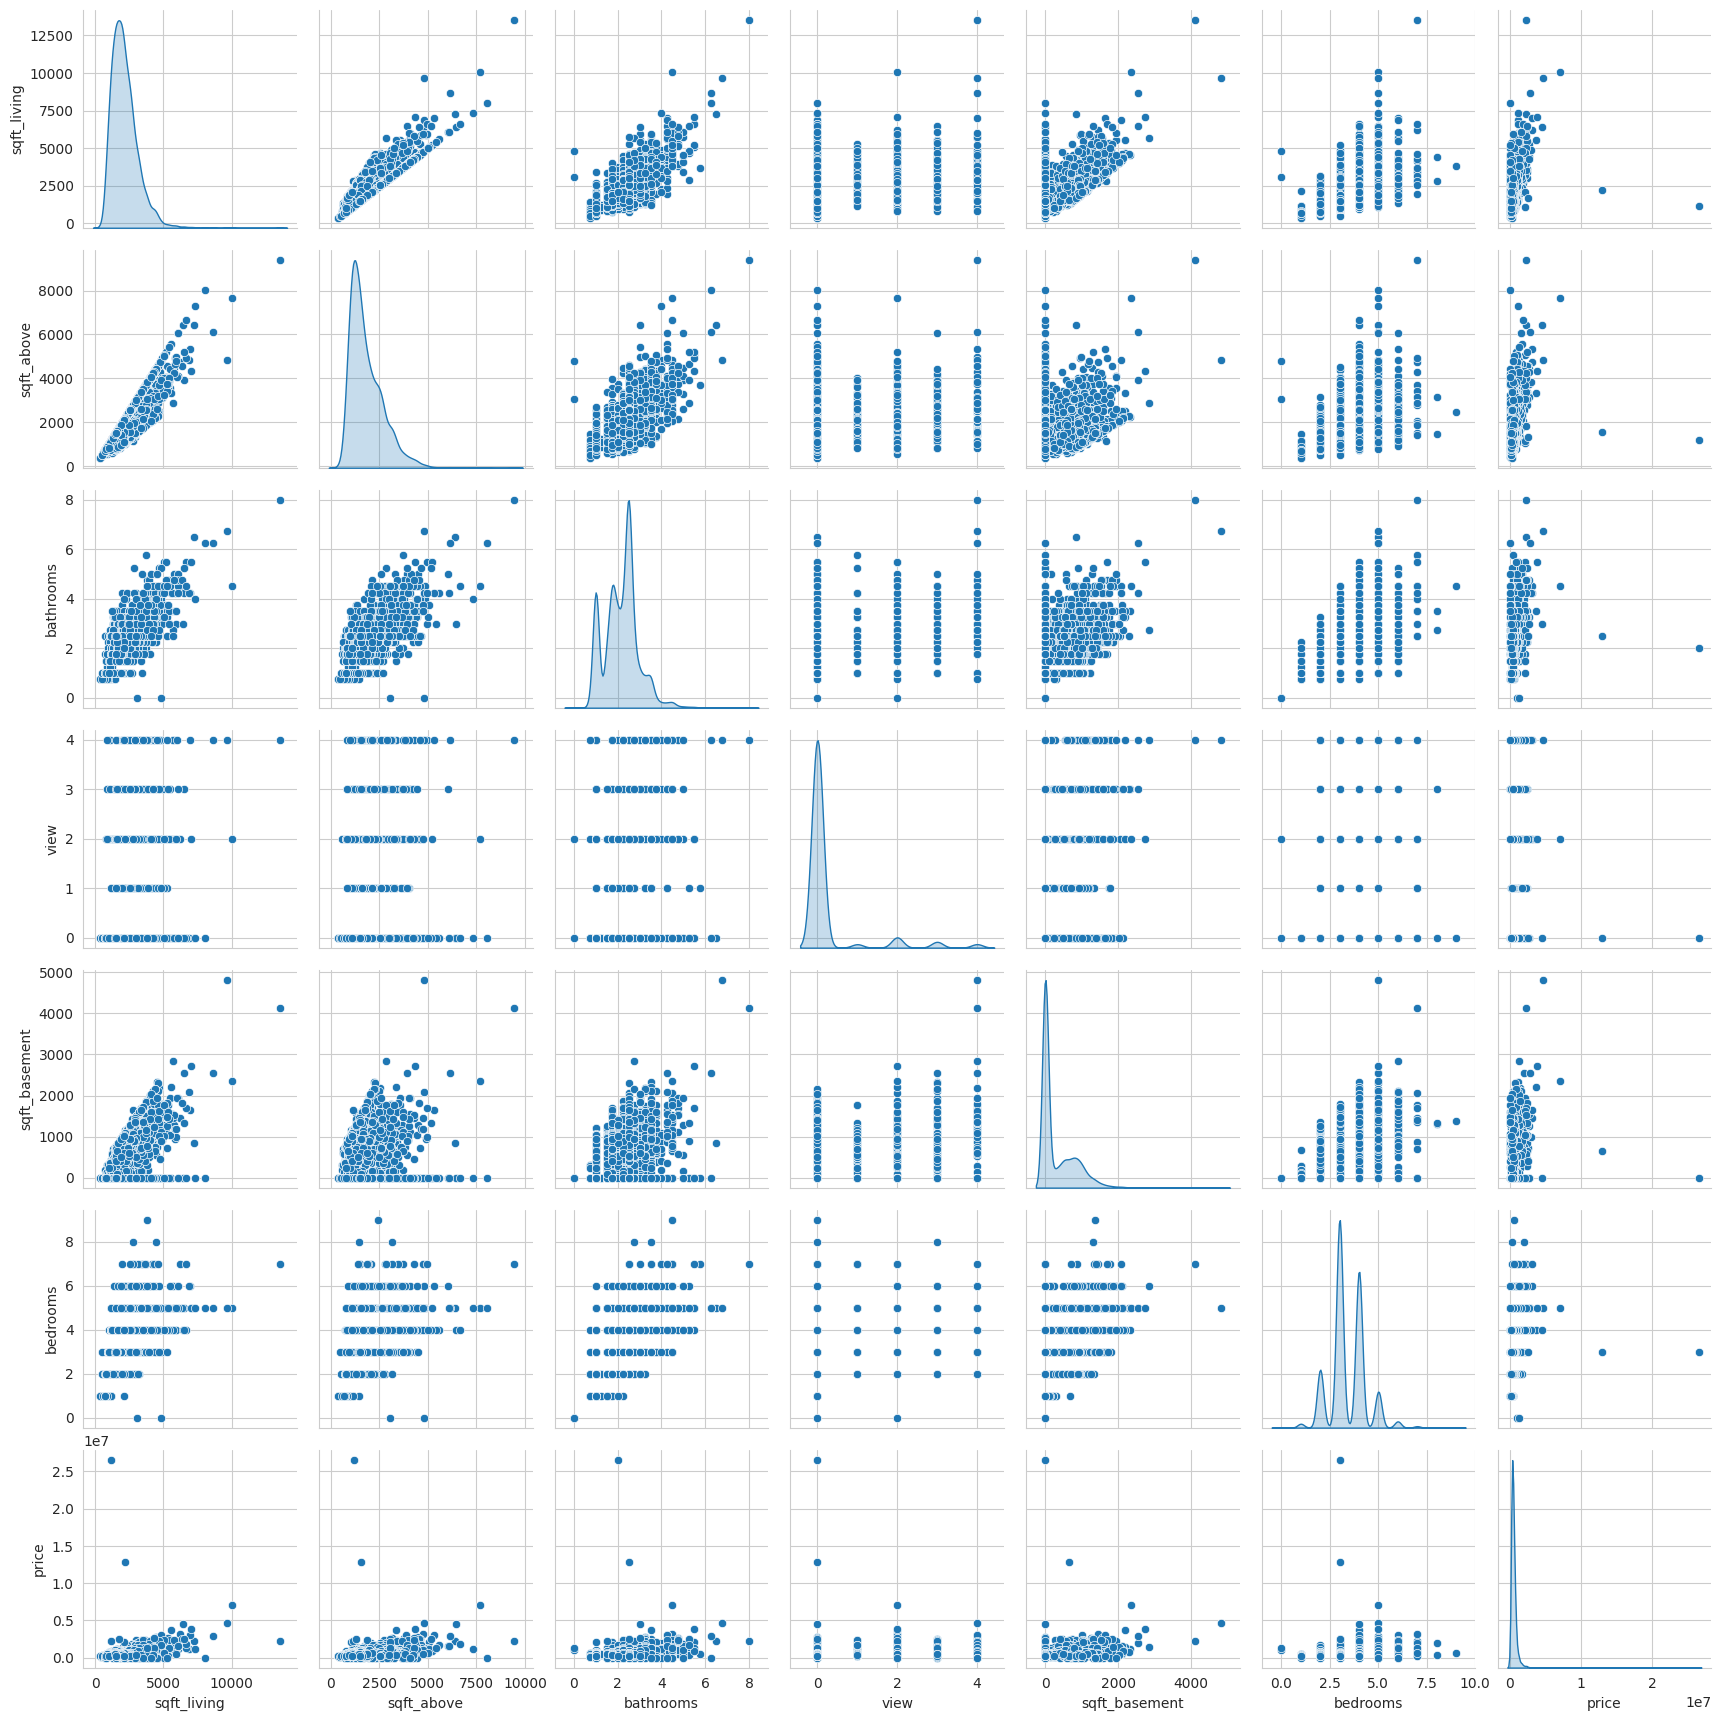

New features added (where possible). Shape: (4600, 25)
Training set size: (3680, 24)
Test set size: (920, 24)

Numeric features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'year', 'month', 'house_age', 'renovated', 'renovation_age', 'total_sqft', 'living_lot_ratio', 'room_count']

Categorical features: ['street', 'city', 'statezip', 'country']

Processed training data shape: (3680, 3777)
Processed test data shape: (920, 3777)

Preprocessor and processed data saved.
X_train shape: (3680, 3777)
X_test shape: (920, 3777)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap


sns.set_style('whitegrid')
%matplotlib inline

DATA_PATH = '../data/raw/UK_House_Prices.csv'
TARGET_COL = 'price'
MODEL_SAVE_DIR = '../models_saved'



os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Check if data file exists
if not os.path.exists(DATA_PATH):
    # Try alternative common paths (useful if switching between local and Colab)
    alt_paths = ['../data/raw/data.csv', './data.csv', 'data.csv']
    found = False
    for p in alt_paths:
        if os.path.exists(p):
            DATA_PATH = p
            found = True
            print(f"Found data at alternative path: {DATA_PATH}")
            break
    if not found:
        raise FileNotFoundError(f"Data file not found at {DATA_PATH} or any alternative paths. Please set the correct DATA_PATH.")


df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

# %%
print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
df.describe(include='all')

# %%
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print("Columns with missing values:")
    print(missing)
else:
    print("No missing values found.")

# %%
# Target variable: 'price'
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[TARGET_COL], bins=50, kde=True)
plt.title('Distribution of Price')

plt.subplot(1, 2, 2)
sns.boxplot(x=df[TARGET_COL])
plt.title('Boxplot of Price')
plt.show()

# %%
# Outliers in price
mean_price = df[TARGET_COL].mean()
std_price = df[TARGET_COL].std()
outliers = df[(df[TARGET_COL] > mean_price + 3*std_price) | (df[TARGET_COL] < mean_price - 3*std_price)]
print(f"Number of outlier properties (price > 3σ): {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# %%
# Date column analysis (if present)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month

    # Average price by year
    yearly_avg = df.groupby('year')[TARGET_COL].mean()
    plt.figure(figsize=(10, 5))
    yearly_avg.plot(marker='o')
    plt.title('Average House Price by Year')
    plt.ylabel('Average Price')
    plt.xlabel('Year')
    plt.grid(True)
    plt.show()
else:
    print("No 'date' column found – skipping time-based plot.")

# %%
# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))

# %%
# Correlation matrix (numeric features)
numeric_df = df.select_dtypes(include=[np.number])
if not numeric_df.empty:
    plt.figure(figsize=(14, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.show()

    # Top correlations with price
    if TARGET_COL in corr.columns:
        price_corr = corr[TARGET_COL].abs().sort_values(ascending=False)
        print("Top 10 features correlated with price:")
        print(price_corr[1:11])  # exclude price itself
    else:
        print(f"Target column '{TARGET_COL}' not found in numeric columns for correlation.")
else:
    print("No numeric columns found – skipping correlation matrix.")

# %%
# Pairplot of important features (optional, may be slow)
if TARGET_COL in df.columns and 'price_corr' in locals():
    top_features = price_corr.index[1:7]  # top 6 features
    # Ensure all features exist in df
    available_features = [f for f in top_features if f in df.columns]
    if available_features:
        sns.pairplot(df[available_features + [TARGET_COL]], diag_kind='kde')
        plt.show()
    else:
        print("Not enough features for pairplot.")

# %% [markdown]
# ## 3. Feature Engineering

# %%
# Create a clean copy for modelling
df_model = df.copy()

# Only create features if the required columns exist
# 1. Date features already extracted (year, month) – keep them if they exist

# 2. Age of house at time of sale (requires 'yr_built')
if 'yr_built' in df_model.columns and 'year' in df_model.columns:
    df_model['house_age'] = df_model['year'] - df_model['yr_built']

# 3. Whether the house was renovated (requires 'yr_renovated')
if 'yr_renovated' in df_model.columns:
    df_model['renovated'] = (df_model['yr_renovated'] > 0).astype(int)

# 4. Years since renovation (if renovated)
if 'yr_renovated' in df_model.columns and 'year' in df_model.columns:
    df_model['renovation_age'] = np.where(df_model['yr_renovated'] > 0, df_model['year'] - df_model['yr_renovated'], 0)

# 5. Total square footage (above + basement)
if 'sqft_above' in df_model.columns and 'sqft_basement' in df_model.columns:
    df_model['total_sqft'] = df_model['sqft_above'] + df_model['sqft_basement']

# 6. Ratio of living area to lot size
if 'sqft_living' in df_model.columns and 'sqft_lot' in df_model.columns:
    df_model['living_lot_ratio'] = df_model['sqft_living'] / df_model['sqft_lot']

# 7. Total rooms (bedrooms + bathrooms)
if 'bedrooms' in df_model.columns and 'bathrooms' in df_model.columns:
    df_model['room_count'] = df_model['bedrooms'] + df_model['bathrooms']

# Drop the original date column if it exists (we already have year/month)
if 'date' in df_model.columns:
    df_model.drop('date', axis=1, inplace=True)

print("New features added (where possible). Shape:", df_model.shape)
df_model.head()

# %% [markdown]
# ## 4. Preprocessing and Data Splitting

# %%
# Separate features and target
if TARGET_COL not in df_model.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found after feature engineering!")

X = df_model.drop(TARGET_COL, axis=1)
y = df_model[TARGET_COL]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# %%
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nNumeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

# %%
# Create preprocessing pipeline
transformers = []
if numeric_features:
    transformers.append(('num', StandardScaler(), numeric_features))
if categorical_features:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features))

if not transformers:
    raise ValueError("No features available for preprocessing – check your data.")

preprocessor = ColumnTransformer(transformers=transformers)

# Fit on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nProcessed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")

# Save preprocessor and processed data
joblib.dump(preprocessor, os.path.join(MODEL_SAVE_DIR, 'preprocessor.pkl'))
np.savez(os.path.join(MODEL_SAVE_DIR, 'processed_data.npz'),
         X_train=X_train_processed, X_test=X_test_processed,
         y_train=y_train.values, y_test=y_test.values)

print("\nPreprocessor and processed data saved.")

# %% [markdown]
# ## 5. Model Training and Comparison

# %%
# Load processed data (to be safe)
data = np.load(os.path.join(MODEL_SAVE_DIR, 'processed_data.npz'))
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# %%
# Dictionary to store results
results = {}

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['Linear Regression'] = {
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    'R2': r2_score(y_test, y_pred_lr)
}
print("Linear Regression done.")

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = {
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'R2': r2_score(y_test, y_pred_rf)
}
print("Random Forest done.")

# 3. XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
results['XGBoost'] = {
    'MAE': mean_absolute_error(y_test, y_pred_xgb),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    'R2': r2_score(y_test, y_pred_xgb)
}
print("XGBoost done.")

# 4. Deep Learning Model
model_dl = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model_dl.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model_dl.fit(X_train, y_train,
                       validation_split=0.2,
                       epochs=50, batch_size=32, verbose=0)

y_pred_dl = model_dl.predict(X_test).flatten()
results['Deep Learning'] = {
    'MAE': mean_absolute_error(y_test, y_pred_dl),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_dl)),
    'R2': r2_score(y_test, y_pred_dl)
}
print("Deep Learning done.")

# %%
# Compare results
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)

# Identify best model (lowest MAE)
best_model_name = results_df['MAE'].idxmin()
print(f"\nBest model: {best_model_name}")

# %%
# Save the best model
best_model_path = os.path.join(MODEL_SAVE_DIR, 'best_model')
if best_model_name == 'Linear Regression':
    joblib.dump(lr, best_model_path + '.pkl')
elif best_model_name == 'Random Forest':
    joblib.dump(rf, best_model_path + '.pkl')
elif best_model_name == 'XGBoost':
    joblib.dump(xgb, best_model_path + '.pkl')
else:  # Deep Learning
    model_dl.save(best_model_path + '.keras')

# Save results
results_df.to_csv(os.path.join(MODEL_SAVE_DIR, 'model_results.csv'))
print("Best model and results saved.")

# %% [markdown]
# ## 6. SHAP Explanations

# %%
# Load test data and best model
data = np.load(os.path.join(MODEL_SAVE_DIR, 'processed_data.npz'))
X_test = data['X_test']
y_test = data['y_test']

if best_model_name == 'Deep Learning':
    import tensorflow as tf
    model = tf.keras.models.load_model(best_model_path + '.keras')
else:
    model = joblib.load(best_model_path + '.pkl')

print(f"Best model: {best_model_name}")

# %%
# SHAP Explanations (using a sample of test data for speed)
X_sample = X_test[:100]

if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample, feature_names=None, show=False)
    plt.title('SHAP Summary Plot (TreeExplainer)')
    plt.show()

elif best_model_name == 'Linear Regression':
    explainer = shap.LinearExplainer(model, data['X_train'][:100])
    shap_values = explainer.shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample, feature_names=None, show=False)
    plt.title('SHAP Summary Plot (LinearExplainer)')
    plt.show()

elif best_model_name == 'Deep Learning':
    background = shap.sample(data['X_train'], 100)
    explainer = shap.KernelExplainer(model.predict, background)
    shap_values = explainer.shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample, feature_names=None, show=False)
    plt.title('SHAP Summary Plot (KernelExplainer)')
    plt.show()

# %% [markdown]
# ## 7. Uncertainty Estimation

# %%
if best_model_name == 'XGBoost':
    # Quantile regression for XGBoost
    xgb_lower = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.1, n_estimators=100, random_state=42)
    xgb_upper = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.9, n_estimators=100, random_state=42)
    xgb_lower.fit(data['X_train'], data['y_train'])
    xgb_upper.fit(data['X_train'], data['y_train'])

    y_lower = xgb_lower.predict(X_test)
    y_upper = xgb_upper.predict(X_test)

    # Save quantile models
    joblib.dump(xgb_lower, os.path.join(MODEL_SAVE_DIR, 'quantile_lower.pkl'))
    joblib.dump(xgb_upper, os.path.join(MODEL_SAVE_DIR, 'quantile_upper.pkl'))
    print("Quantile models saved.")

    # Example intervals
    print("\nPrediction intervals (first 10 test samples):")
    for i in range(10):
        pred = model.predict(X_test[i:i+1])[0]
        print(f"Sample {i}: true={y_test[i]:.0f}, pred={pred:.0f}, interval=[{y_lower[i]:.0f}, {y_upper[i]:.0f}]")

elif best_model_name == 'Deep Learning':
    # Monte Carlo Dropout
    predictions = np.stack([model(X_test, training=True) for _ in range(100)])
    pred_mean = predictions.mean(axis=0)
    pred_std = predictions.std(axis=0)
    y_lower = pred_mean - 1.96 * pred_std
    y_upper = pred_mean + 1.96 * pred_std
    print("MC Dropout intervals computed.")

    print("\nPrediction intervals (first 10 test samples):")
    for i in range(10):
        print(f"Sample {i}: true={y_test[i]:.0f}, pred={pred_mean[i]:.0f}, interval=[{y_lower[i]:.0f}, {y_upper[i]:.0f}]")

else:
    print("Uncertainty estimation not implemented for this model type.")

